# Imports and reproducability

Imports

In [1]:
from typing import Dict, Tuple, Any
import random

from transformers import AutoTokenizer, BatchEncoding
from datasets import Dataset as ds
from sklearn.model_selection import train_test_split
from pathlib import Path
import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

from transformers import (
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


Reproducability

In [2]:
def set_seed(seed: int = 67) -> None:
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Code from data_handler.py

In [15]:
N_TRAIN = 500
N_VAL = 100
N_TEST = 100
MASK = "<mask>"
MASK_WORDS = [
    "investor",
    "stocks",
    "sales",
    "company",
    "market",
    "internet",
    "microsoft",
    "google",
    "software",
    "technology",
    "game",
    "olympic",
    "coach",
    "season",
    "league",
    "president",
    "world",
    "national",
    "oil",
    "government",
]


def _get_raw_data(path: str) -> Dict[str, ds]:
    """
    Load the raw dataset from CSV files, split the training data into
    training and validation sets, and convert them to HuggingFace datasets.

    Args:
        path: path to the directory containing the dataset CSV files

    Returns:
        Dictionary containing three datasets:
            - train: training dataset
            - validation: validation dataset
            - test: test dataset
    """
    train_data = pd.read_csv(path + "/train.csv")
    test_data = pd.read_csv(path + "/test.csv")

    train_data, validation_data = train_test_split(
        train_data, test_size=0.1, random_state=67
    )

    X_train = pd.DataFrame(
        {
            "text": train_data["Title"] + train_data["Description"],
            "label": [idx - 1 for idx in train_data["Class Index"]],
        }
    )
    X_validation = pd.DataFrame(
        {
            "text": validation_data["Title"] + validation_data["Description"],
            "label": [idx - 1 for idx in validation_data["Class Index"]],
        }
    )
    X_test = pd.DataFrame(
        {
            "text": test_data["Title"] + test_data["Description"],
            "label": [idx - 1 for idx in test_data["Class Index"]],
        }
    )

    return {
        "train": ds.from_pandas(X_train, preserve_index=False),
        "validation": ds.from_pandas(X_validation, preserve_index=False),
        "test": ds.from_pandas(X_test, preserve_index=False),
    }


def _get_smaller_datasets(
    raw: Dict[str, ds],
) -> Tuple[ds, ds, ds]:
    """
    Create smaller subsets of the datasets for faster experimentation.

    Args:
        raw: Dictionary containing the original datasets ("train",
        "validation", and "test").

    Returns:
        A tuple containing:
            - training dataset
            - validation dataset
            - test dataset
    """
    train = raw["train"].shuffle(seed=67).select(range(N_TRAIN))
    validation = raw["validation"].shuffle(seed=67).select(range(N_VAL))
    test = raw["test"].select(range(N_TEST))
    return train, validation, test


def _get_datasets(raw: Dict[str, ds]) -> Tuple[ds, ds, ds]:
    """
    Retrieve the datasets used for training, validation, and testing.

    Args:
        raw: Dictionary containing the datasets ("train",
        "validation", and "test".)

    Returns:
        A tuple containing:
            - training dataset
            - validation dataset
            - test dataset
    """
    train = raw["train"].shuffle(seed=67)  # We only shuffle the training set
    validation = raw["validation"]
    test = raw["test"]
    return train, validation, test


def _tokenize_function(dataset: ds) -> BatchEncoding:
    """
    Tokenizes the texrt samples in a provided dataset, using the best tokenizer for RoBERTa
    Args:
        samples (ds): dataset with text samples

    Returns:
        : the tokenized samples
    """
    tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")
    return tokenizer(dataset["text"], padding="max_length",max_length=100, truncation=True, seed=67)

def _plot_lens(data) -> None:
    """Plot distribution of lengths in the training set"""
    tokenized_data = data.map(_tokenize_function, batched=True)
    lengths = [len(text['input_ids']) for text in tokenized_data]
    plt.hist(lengths, bins=50)
    plt.title("Distribution of tokenized text lengths in training set")
    plt.xlabel("Length of tokenized text")
    plt.ylabel("Frequency")
    plt.show()


def _mask(dataset: pd.DataFrame) -> pd.DataFrame:
    """
    Masks field-specific words from a dataset with text samples with '<mask>'

    Args:
        dataset (pd.DataFrame): dataset with text samples

    Returns:
        pd.DataFrame: the samples with masked field-specific words
    """
    new = []
    for text in dataset["text"]:
        for word in MASK_WORDS:
            text = text.replace(word, MASK)
        new.append(text)
    dataset.drop(["text"], axis=1)
    dataset["text"] = new
    return dataset


def get_preprocessed_data(
    path: str, small: bool = False
) -> tuple[BatchEncoding, BatchEncoding, BatchEncoding]:
    """
    Gets data from a provided path, divides it into training, validation, and test sets, and tokenizes it

    Args:
        path (str): path to the folder in which the data is stored
        small (bool, optional): when small is True, a small fraction of the dataset is used

    Returns:
        tuple[BatchEncoding, BatchEncoding, BatchEncoding]: tokenized data, devided into training, validation, and testing data
    """
    raw = _get_raw_data(path)
    if small:
        train_dataset, val_dataset, test_dataset = _get_smaller_datasets(raw)
    else:
        train_dataset, val_dataset, test_dataset = _get_datasets(raw)
    # _plot_lens(train_dataset)
    tokenized_train = train_dataset.map(_tokenize_function, batched=True)
    tokenized_val = val_dataset.map(_tokenize_function, batched=True)
    tokenized_test = test_dataset.map(_tokenize_function, batched=True)

    return tokenized_train, tokenized_val, tokenized_test


def get_only_headline_test_dataset(path: str) -> BaseException:
    """
    Gets only the headlines in the testing data from a path and tokenizes it

    Args:
        path (str): path to the folder in which the data is stored

    Returns:
        BaseException: tokenized testing data with only headlines
    """
    test_data = pd.read_csv(path + "/test.csv")
    X_test = pd.DataFrame(
        {
            "text": test_data["Title"],
            "label": [idx - 1 for idx in test_data["Class Index"]],
        }
    )
    X_test = ds.from_pandas(X_test, preserve_index=False)
    return X_test.map(_tokenize_function, batched=True)


def get_masked_test_dataset(path) -> BaseException:
    """
    Masks field-specific words in the testing data from a path and tokenizes it

    Args:
        path (str): path to the folder in which the data is stored

    Returns:
        BaseException: tokenized testing data with masked field-specific words
    """
    test_data = pd.read_csv(path + "/test.csv")
    X_test = pd.DataFrame(
        {
            "text": test_data["Title"] + test_data["Description"],
            "label": [idx - 1 for idx in test_data["Class Index"]],
        }
    )

    X_test = _mask(X_test)
    X_test = ds.from_pandas(X_test, preserve_index=False)
    return X_test.map(_tokenize_function, batched=True)


# Code from evaluation.py

In [4]:
def plot_confusion_matrix(
    model: Any, dataset: pd.DataFrame, model_name: str, dataset_name: str
) -> None:
    """
    Function evaluates the classification and saves its confusion matrix.

    Arguments:
        y_true: Series- True labels.
        y_predict: Series- Predicted labels.
        model_name: str- Name of the model.
        dataset: str- Dataset identifier.

    Returns: None
    """
    results = model.predict(dataset)
    y_predict = [np.argmax(a) for a in results[0]]
    y_true = dataset["label"]
    Path("plots").mkdir(exist_ok=True)
    print(classification_report(y_true, y_predict))

    cm = confusion_matrix(y_true, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(xticks_rotation="vertical")

    # plt.savefig(f"plots/confusion_matrix_{model_name}_{dataset_name}")
    plt.show()
    plt.close()


# Code from main.py

Get data and fine-tune the model

In [17]:
set_seed()
train_dataset, val_dataset, test_dataset = get_preprocessed_data("data")

model_name = "FacebookAI/roberta-base"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

training_args = TrainingArguments(
    eval_strategy="steps",
    eval_steps=106,
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=1024,
    per_device_eval_batch_size=1024,
    num_train_epochs=10,
    weight_decay=0.01,
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
    save_steps=106,
    seed=67,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()




Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=848, training_loss=0.16336049111384265, metrics={'train_runtime': 955.0331, 'train_samples_per_second': 1130.851, 'train_steps_per_second': 1.11, 'total_flos': 4.44007878912e+16, 'train_loss': 0.16336049111384265, 'epoch': 8.0})

Test on the validation dataset

Validation Results: {'eval_loss': 0.15867476165294647, 'eval_runtime': 4.9919, 'eval_samples_per_second': 2403.901, 'eval_steps_per_second': 2.404, 'epoch': 8.0}
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      3052
           1       0.99      0.99      0.99      2984
           2       0.93      0.91      0.92      2953
           3       0.92      0.93      0.93      3011

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



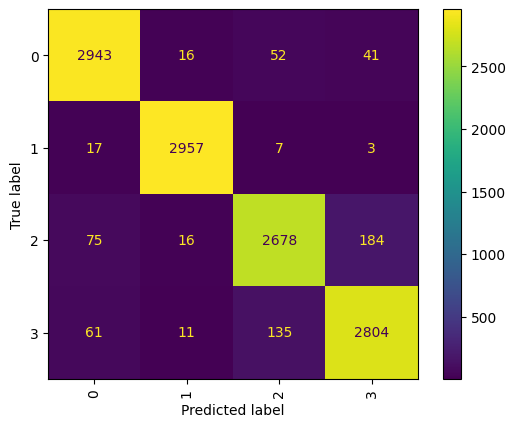

In [18]:
# accuracy + F1 on validation set
evaluation_val = trainer.evaluate(val_dataset)
print(f"Validation Results: {evaluation_val}")
# confusion matrix on validation set
plot_confusion_matrix(trainer, val_dataset, model_name, "validation dataset")

Test on the test dataset

Test Results: {'eval_loss': 0.16601713001728058, 'eval_runtime': 3.1652, 'eval_samples_per_second': 2401.11, 'eval_steps_per_second': 2.527, 'epoch': 8.0}
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1900
           1       0.99      0.99      0.99      1900
           2       0.93      0.91      0.92      1900
           3       0.92      0.93      0.93      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



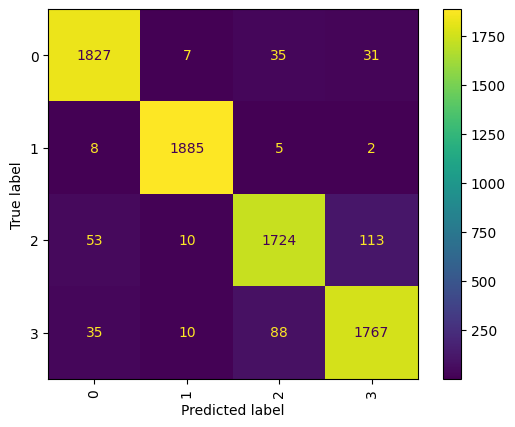

In [19]:
# accuracy + F1 on test set
evaluation_test = trainer.evaluate(test_dataset)
print(f"Test Results: {evaluation_test}")
# confusion matrix on test set
plot_confusion_matrix(trainer, test_dataset, model_name, "test dataset")

Test on the test dataset with only headlines

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Headlines Results: {'eval_loss': 0.7416132688522339, 'eval_runtime': 3.1529, 'eval_samples_per_second': 2410.465, 'eval_steps_per_second': 2.537, 'epoch': 8.0}
              precision    recall  f1-score   support

           0       0.64      0.93      0.76      1900
           1       0.93      0.64      0.76      1900
           2       0.86      0.71      0.78      1900
           3       0.82      0.84      0.83      1900

    accuracy                           0.78      7600
   macro avg       0.81      0.78      0.78      7600
weighted avg       0.81      0.78      0.78      7600



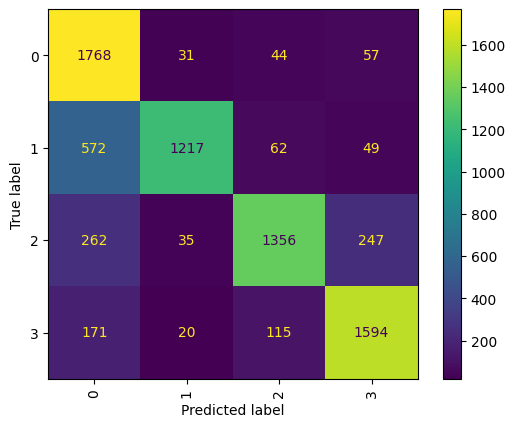

In [20]:
# Robustness with headlines vs headlines+description
headlines_test_dataset = get_only_headline_test_dataset("data")
# accuracy + F1 on test set
headlines_evaluation_test = trainer.evaluate(headlines_test_dataset)
print(f"Headlines Results: {headlines_evaluation_test}")
# confusion matrix on test set
plot_confusion_matrix(trainer, headlines_test_dataset, model_name, "headlines test")


Test on the test dataset with masked field-specific words

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Masked Results: {'eval_loss': 0.17188425362110138, 'eval_runtime': 3.1642, 'eval_samples_per_second': 2401.833, 'eval_steps_per_second': 2.528, 'epoch': 8.0}
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1900
           1       0.99      0.99      0.99      1900
           2       0.93      0.90      0.92      1900
           3       0.92      0.93      0.92      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



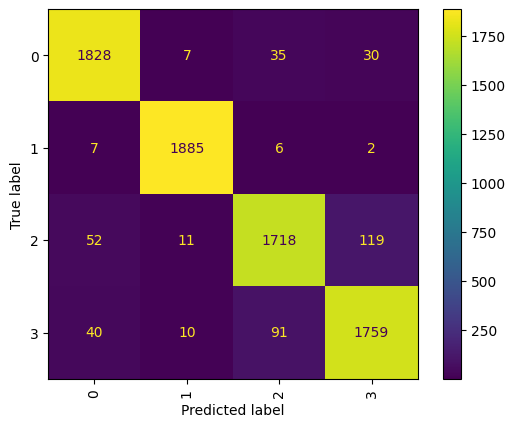

In [21]:
# Robustness with keyword masking
mask_test_dataset = get_masked_test_dataset("/content/data")
# accuracy + F1 on test set
mask_evaluation_test = trainer.evaluate(mask_test_dataset)
print(f"Masked Results: {mask_evaluation_test}")
# confusion matrix on test set
plot_confusion_matrix(trainer, mask_test_dataset, model_name, "mask dataset")
